In [1]:
import sys
import os
sys.path.append('../scripts/')
from visualization import PhenologyVisualization
from functions import datenum_to_datetime, bivariate_legend
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import netCDF4
from datetime import datetime
import matplotlib.dates as mdates
import colorcet as cc
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
lakeid = 310
i , j = 62,72
# lakeid = 2
# i , j = 23, 30

In [3]:
#version 3.0
pc_phenology_path_v3 = f"D:\\phenology_data\\v3.0\\phenology\\phycocyanin\\{lakeid}.nc"
pc_extract_path_v3 = f"D:\\phenology_data\\v3.0\\extract\\phycocyanin\\{lakeid}.nc"

chl_phenology_path_v3 = f"D:\\phenology_data\\v3.0\\phenology\\chla\\{lakeid}.nc"
chl_extract_path_v3 = f"D:\\phenology_data\\v3.0\\extract\\chla\\{lakeid}.nc"


In [4]:
PhenologyVisualization.set_shapefile_path(r"C:\Users\schelian\Downloads\lakes_cci_v2.1.0_shp\shapefile\lakescci_v2.1.0_data-availability.shp")

In [5]:
# load classes
# phyco_v3 = PhenologyVisualization(pc_extract_path_v3, pc_phenology_path_v3)
chla_v3 = PhenologyVisualization(chl_extract_path_v3, chl_phenology_path_v3)

In [6]:
%matplotlib inline

## Interactive plotting
To activate an interactive environment, use `%matplotlib widget`. To exit, call `plt.close('all')` before `%matplotlib inline` in the same cell — this clears matplotlib's open figure registry so widget figures are not re-rendered as static images when the backend switches.

15

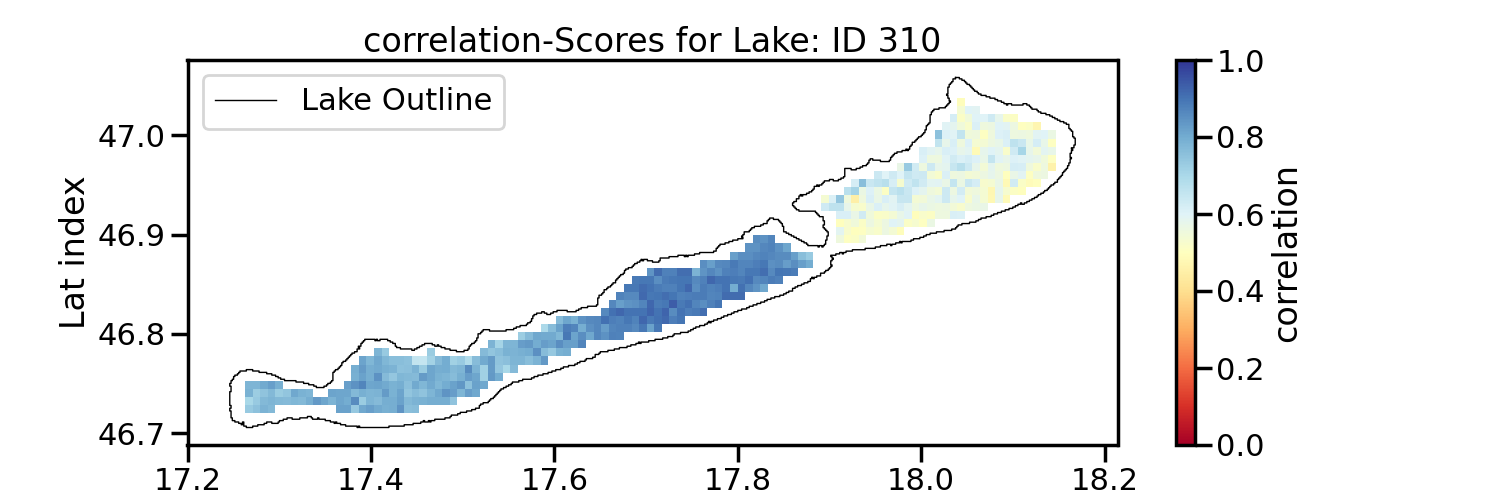

In [413]:
%matplotlib widget
fig, ax = plt.subplots(1,1,figsize=(15,5))
chla_v3.interactive_metric_map(chla_v3.correlation_scores(time_split=[[1998,2028]]),'correlation',fig,ax)

c:\Users\schelian\cci-cyano-production\notebooks\../scripts\functions.py:254: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


'Badabag'

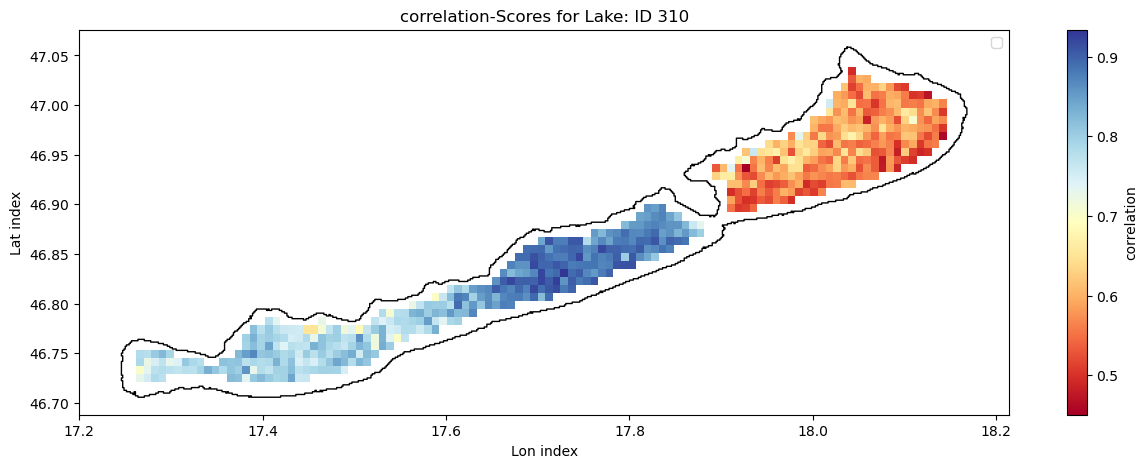

In [7]:
plt.close('all')
%matplotlib inline
fig, ax = plt.subplots(1,1,figsize=(15,5))
chla_v3.metric_map(chla_v3.correlation_scores(time_split=[[2002,2024]]),'correlation',fig,ax)

chla_v3.ID_to_name(8089)

## Times series plots
Examples of how to edit plots

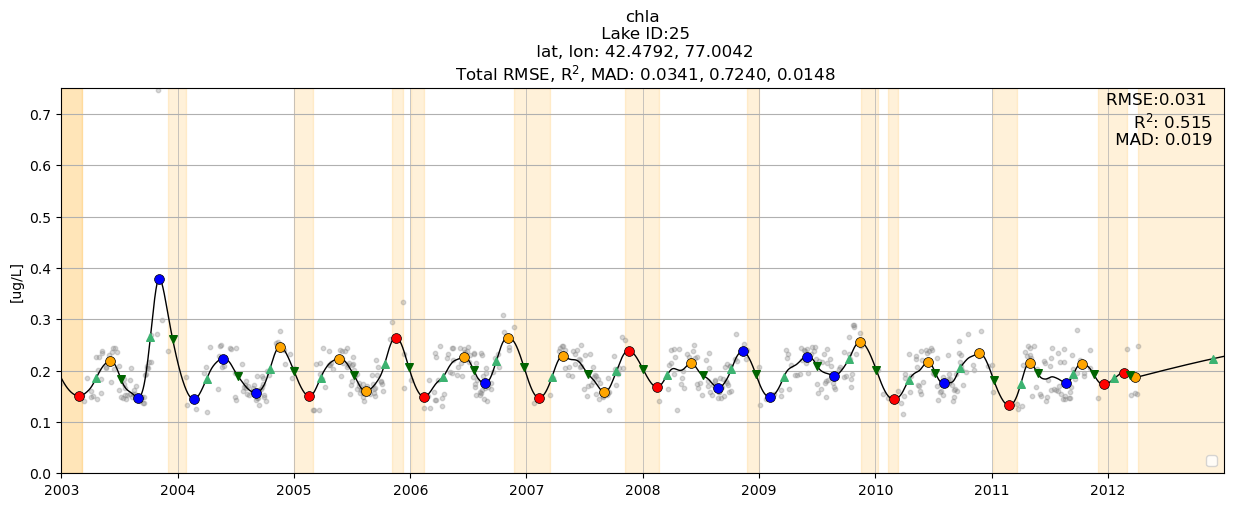

In [389]:
# Implement a time series plot of the cubic spline and background data
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(i,j, ax, aggregation=False,start=2003, end= 2012)

ax.set_ylim(0,0.75)
ax.legend('')
ax.texts[0].set_fontsize(12)

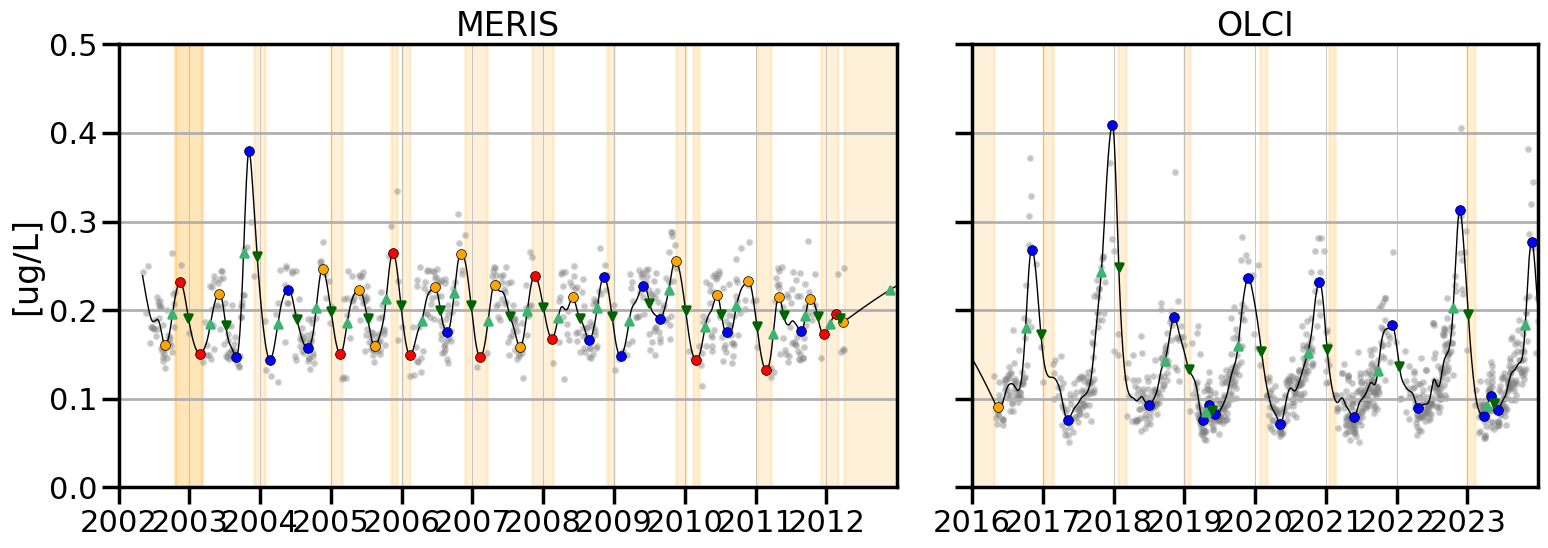

In [407]:
# Implement a split plot with formatting edits after creation.
fig, axs = plt.subplots(1,2, figsize = (16,6),width_ratios=[11,8])
sns.set_context('poster')
chla_v3.split_plot(ax0 = axs[0], ax1=axs[1],latitude_idx = i,longitude_idx = j, aggregation=False,end0 = 2012,start1 = 2016)
axs[0].set_title("MERIS")
axs[1].set_title("OLCI")
axs[0].set_ylim(0,0.5)
axs[1].set_ylim(0,0.5)

axs[1].set_ylabel('')
axs[1].set_yticklabels([])
axs[0].get_legend().remove()
axs[1].get_legend().remove()


axs[0].texts[0].remove()
axs[1].texts[0].remove()

plt.tight_layout()


In [2]:
1.68e-5*365**2

2.23818

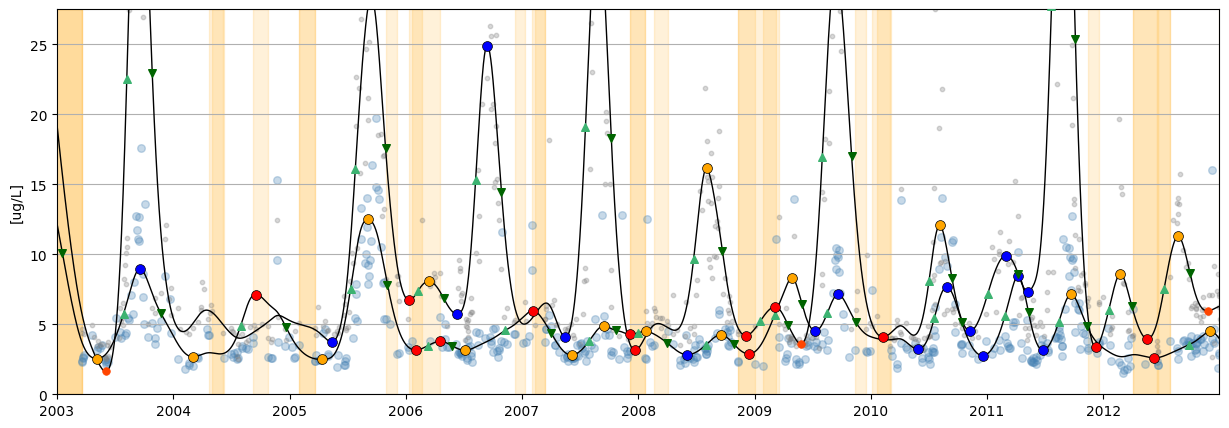

In [10]:
# Plot the splines and data from two pixels on the same plot, with formatting edits.
fig, ax = plt.subplots(1,1,figsize=(15,5))

chla_v3.single_plot(i,j, ax, aggregation=False,start=2003, end= 2012)
ax.collections[0].set(color = 'steelblue')
ax.collections[0].set_sizes([30])
chla_v3.single_plot(16,57, ax, aggregation=False, start=2003,end= 2012)
ax.collections[-5].set(color = 'orangered',sizes=[30])
for txt in ax.texts:
    txt.remove()
ax.get_legend().remove()
ax.set_ylim(0,27.5)
ax.set_title("")
ax.grid()

c:\Users\sparksno\Documents\GitHub\cci-cyano-production\notebooks\../scripts\visualization.py:2068: UserWarning: No peaks/troughs available for 2014-2014; using automatic y-limits.
  warnings.warn(


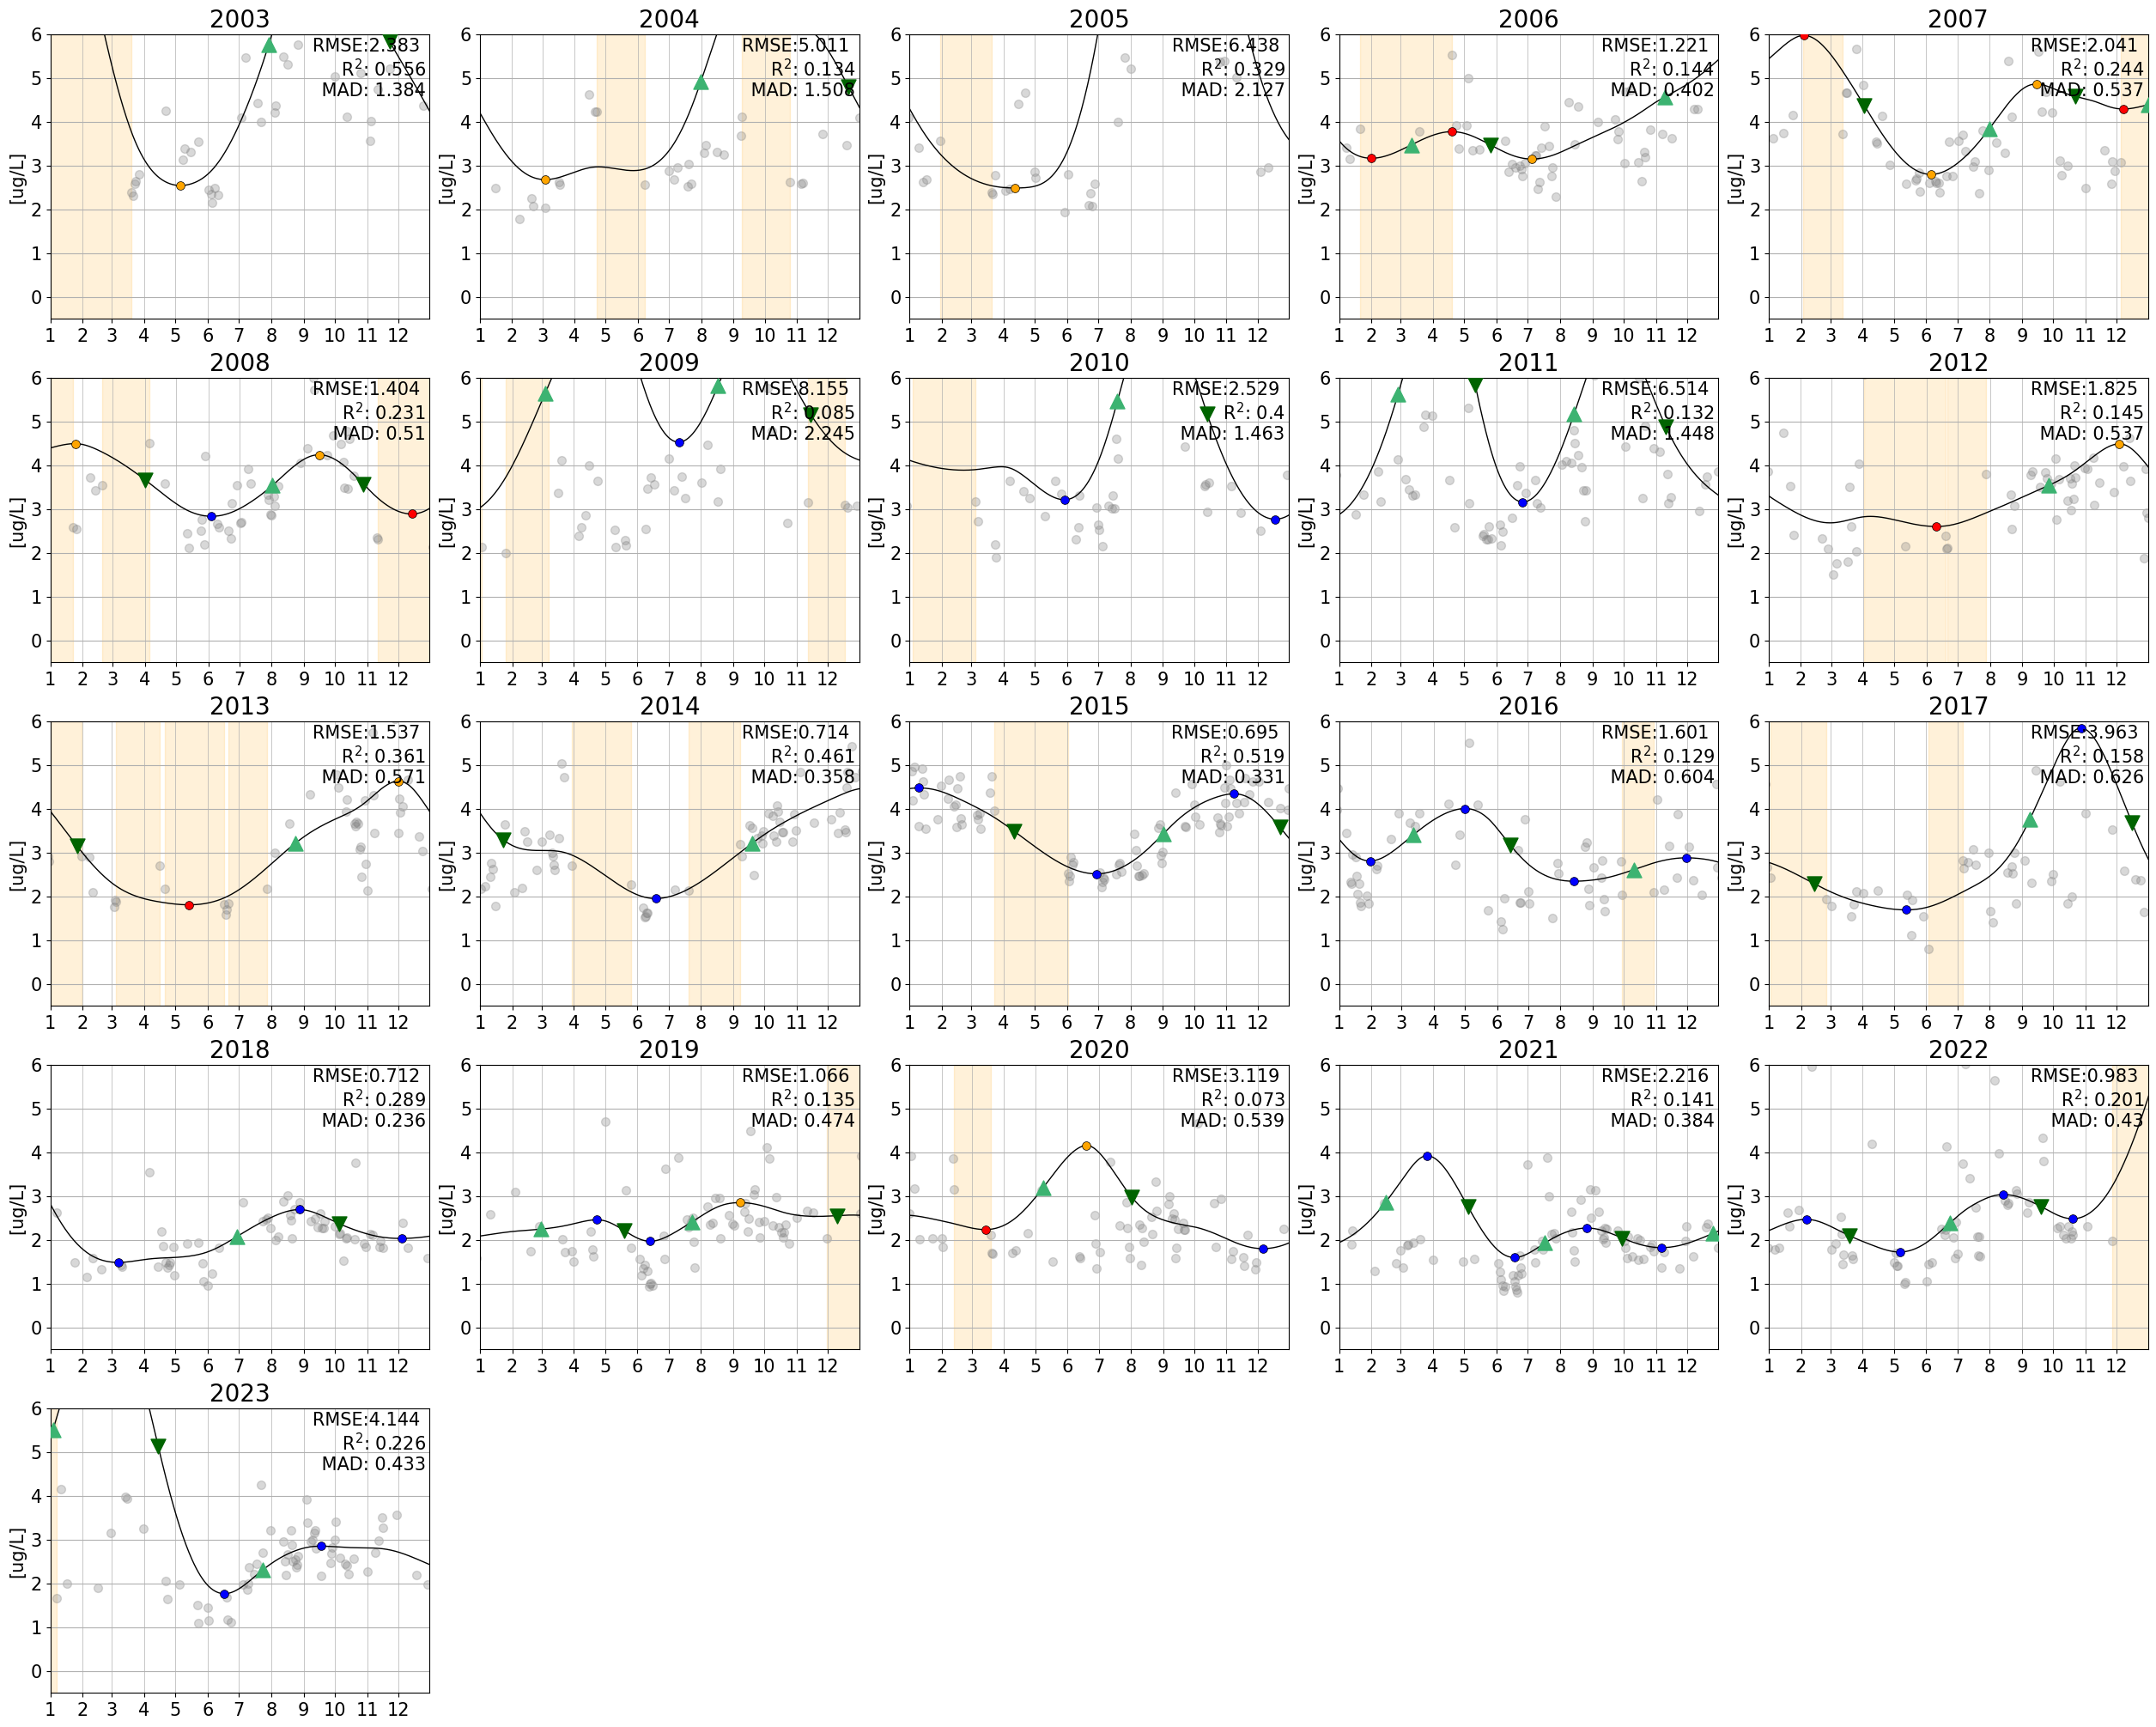

In [11]:
# Compare single years
years = [2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]

chla_v3.single_years_plot(i, j, years = years, ncol = 5, nrow = 5, annotation = ["R2", "RMSE"], ylim = (-0.5,6))

c:\Users\schelian\cci-cyano-production\notebooks\../scripts\visualization.py:3751: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(f.to_frac_month(trgs_x_sub[tm]), trgs_y_sub[tm], color="darkgray", s=50,
c:\Users\schelian\cci-cyano-production\notebooks\../scripts\visualization.py:3747: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(f.to_frac_month(pks_x_sub[pm]), pks_y_sub[pm], color="black", s=50,
c:\Users\schelian\cci-cyano-production\notebooks\../scripts\visualization.py:3755: UserWarning: Not enough data to plot for year 2024
  warnings.warn(f"Not enough data to plot for year {year}")


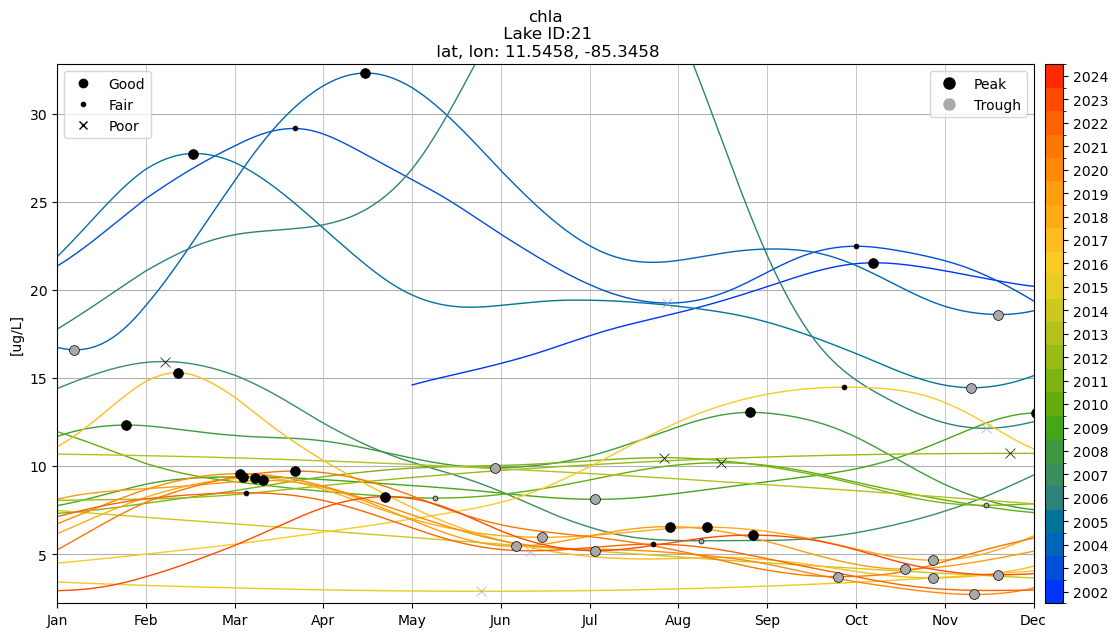

In [9]:
# plot multiple years in the same plot
fig, ax = plt.subplots(1,1, figsize = (15,7))

meris_years = [2003,2004,2005,2006,2007,2008,2009,2010,2011]
olci_years = list(np.arange(2017,2024))

chla_v3.yearly_cubic_spline(ax, i,j,years=None)
# ax.set_ylim(-5,30)

# plot the ratio of non aggregated background points

fig, ax = plt.subplots(1,1,figsize=(15,5))

phyco_v3.plot_background_ratio_timeseries(chla_v3,ax,i,j,color="purple" )

## Comparison Plots
compare different versions and phenology variables with eath other

Text(0.5, 1.0, '')

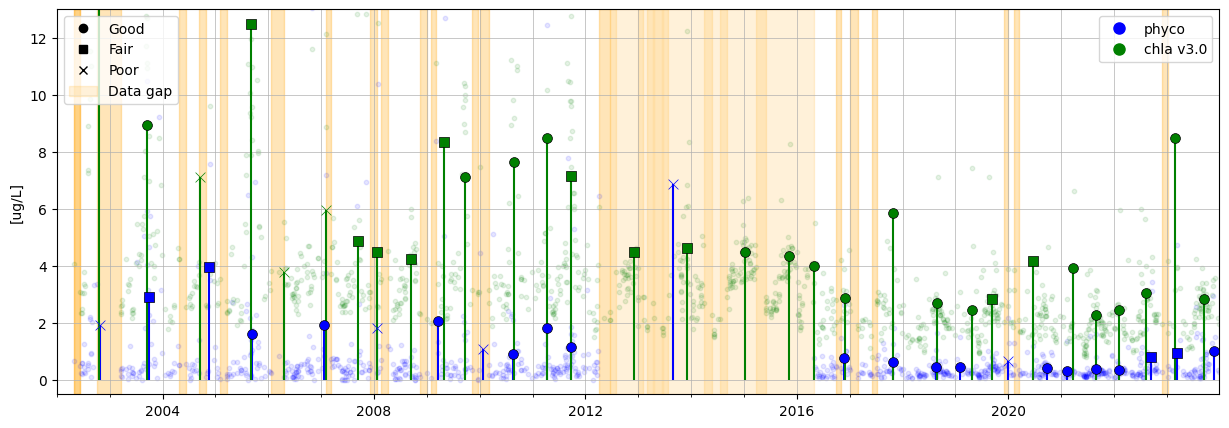

In [9]:
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.extrema_comparison(chla_v3, i,j, ax)
ax.set_title("")

Text(0.5, 1.0, '')

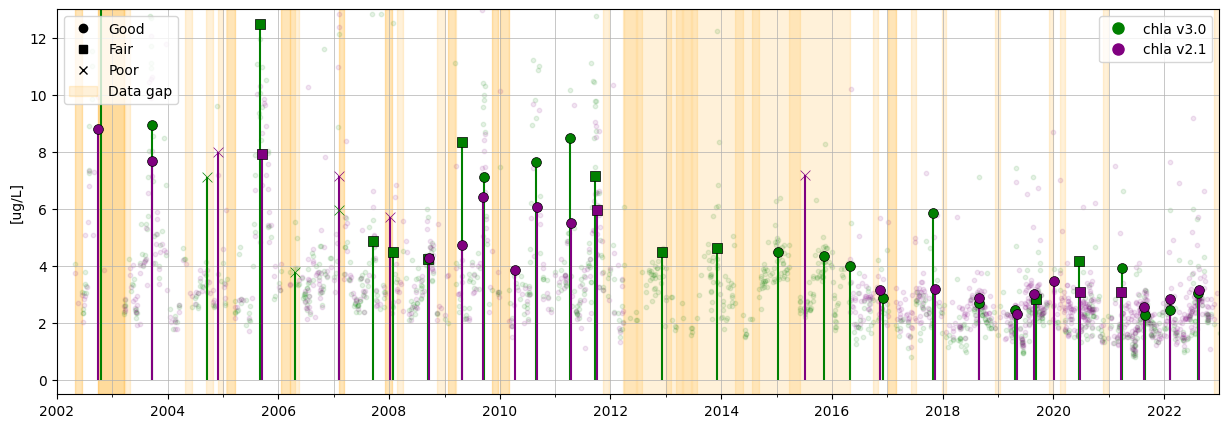

In [10]:
fig, ax = plt.subplots(1,1,figsize=(15,5))
chla_v3.extrema_comparison(chla_v2, i,j, ax, purple_chla21=True)
ax.set_title("")

## Maps

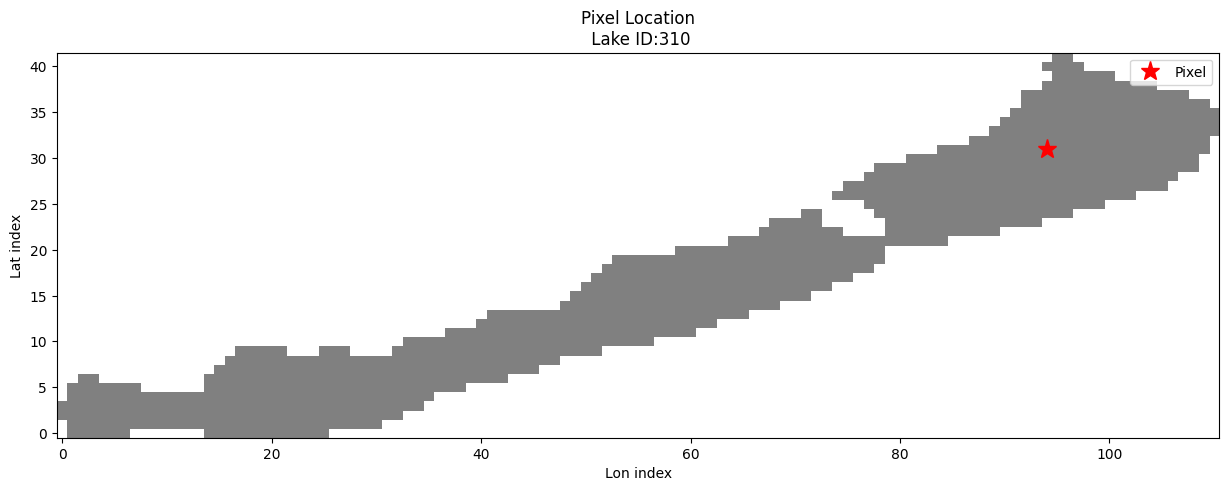

In [15]:
# Plot where a Pixel is located
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.pixel_map(i,j, ax)

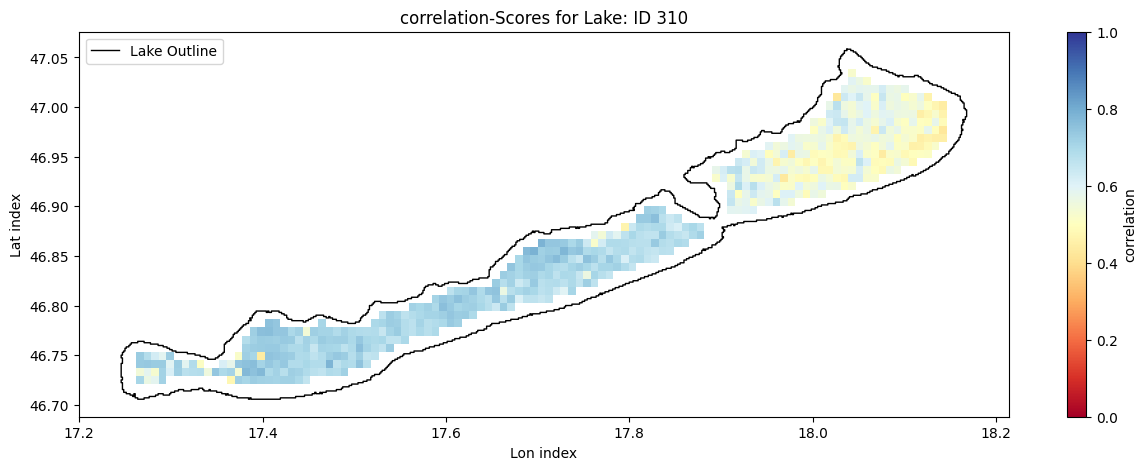

In [16]:
# Plot a metric map
fig, ax = plt.subplots(1,1,figsize=(15,5))
phyco_v3.metric_map(phyco_v3.correlation_scores(time_split = [[2002,2024]]),'correlation',fig,ax,'RdYlBu')

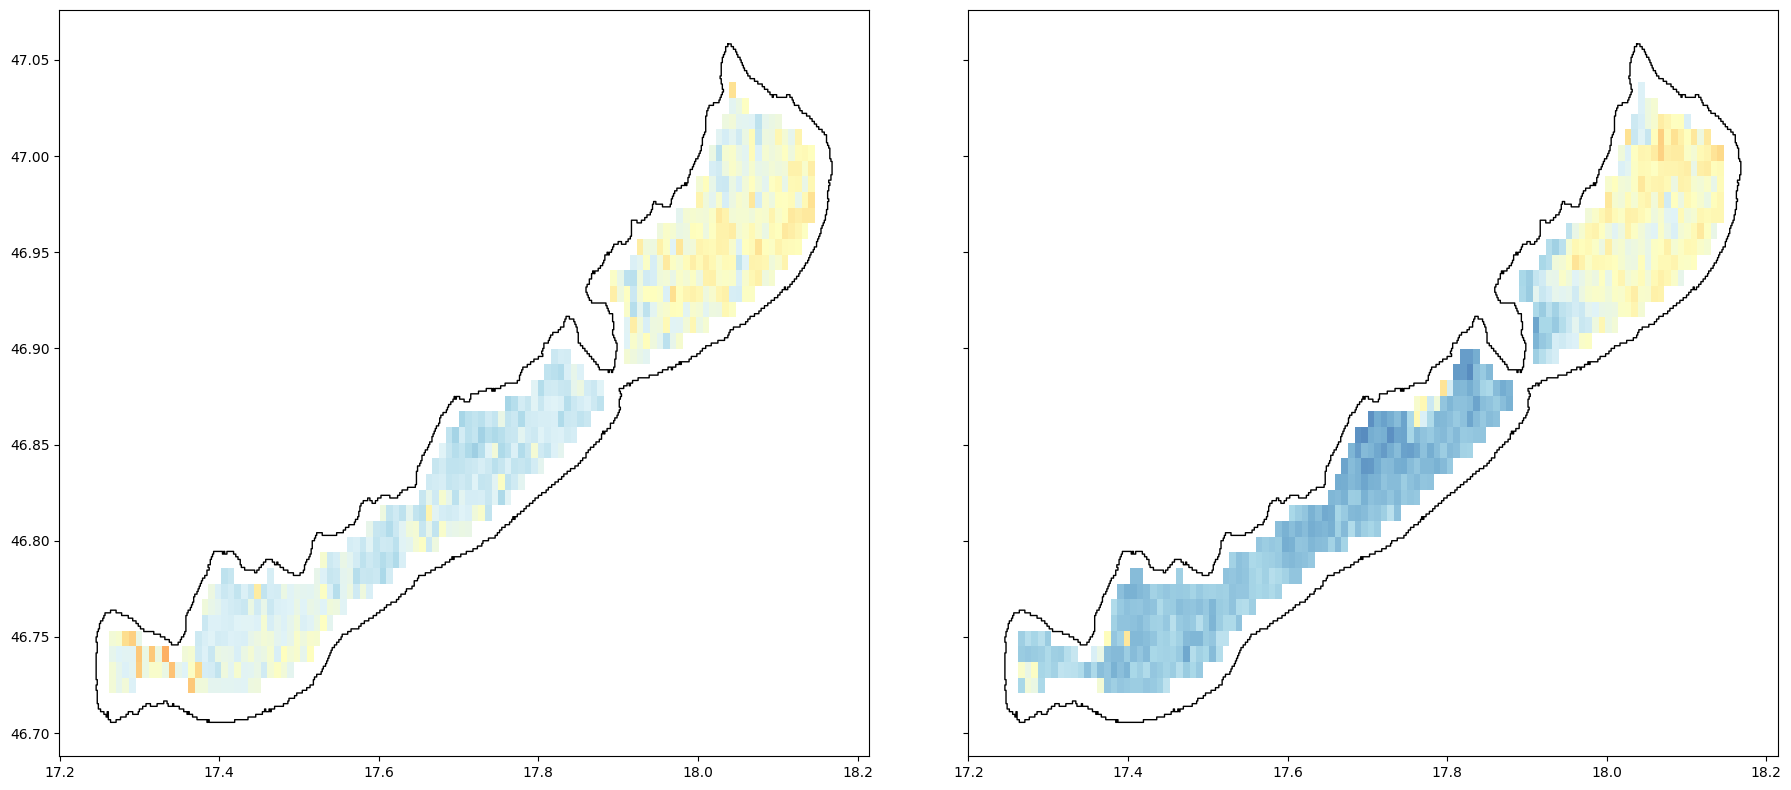

In [17]:
# Plot two maps with formatting edits after map creation.
fig, axs = plt.subplots(1,2, figsize = (20,8))
cmap = 'RdYlBu'
colorbar_extent = [0,1]
phyco_v3.metric_map(phyco_v3.correlation_scores(time_split = [[2002,2012]]),'RMSE', fig, axs[0],cmap, colorbar_extent= colorbar_extent)
phyco_v3.metric_map(phyco_v3.correlation_scores(time_split = [[2016,2024]]),'RMSE', fig, axs[1],cmap, colorbar_extent= colorbar_extent)

fig.axes[-1].remove()
fig.axes[-1].remove()

axs[0].set_xlabel('')
axs[1].set_xlabel('')
axs[0].set_ylabel('')
axs[1].set_ylabel('')

axs[1].set_yticklabels([])
axs[0].get_legend().remove()
axs[1].get_legend().remove()
axs[0].set_title('')
axs[1].set_title('')
plt.tight_layout()

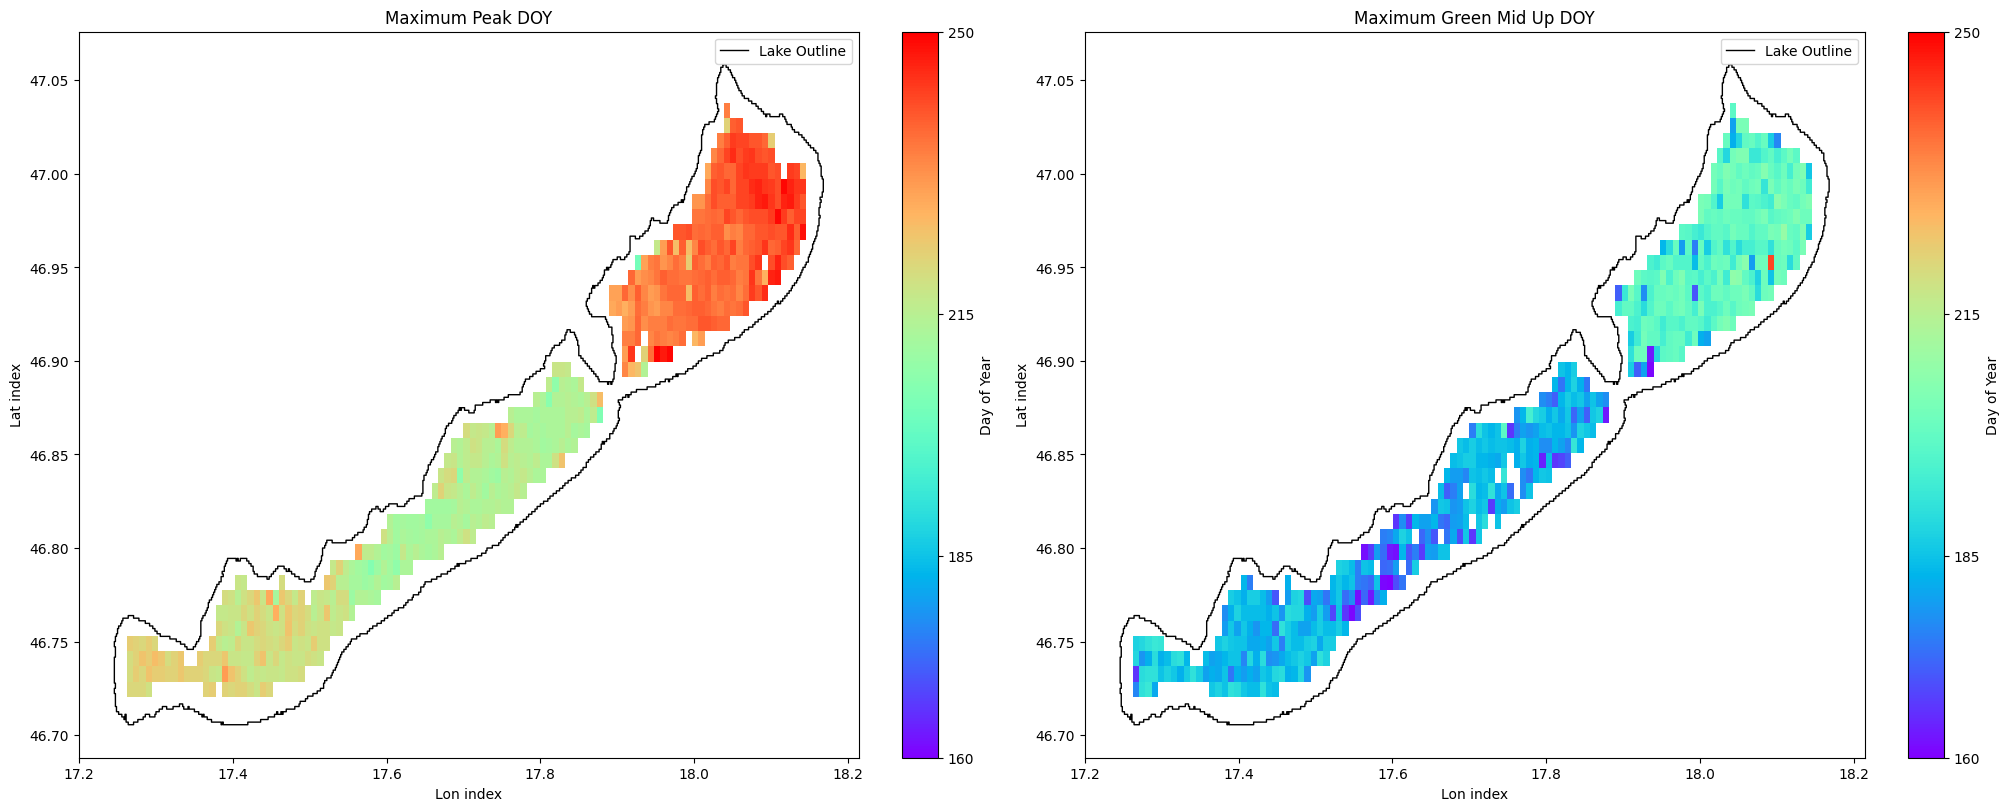

In [18]:
# Plotting the DOY the maximum peak and maximum green mid up occured 
fig, axs = plt.subplots(1,2,figsize = (20,8), constrained_layout = True)
chla_v3.time_map(fig, axs[0], year = 2010, peaks = True)
chla_v3.time_map(fig, axs[1], year = 2010, peaks = False)

axs[0].set_title("Maximum Peak DOY")
axs[1].set_title("Maximum Green Mid Up DOY");


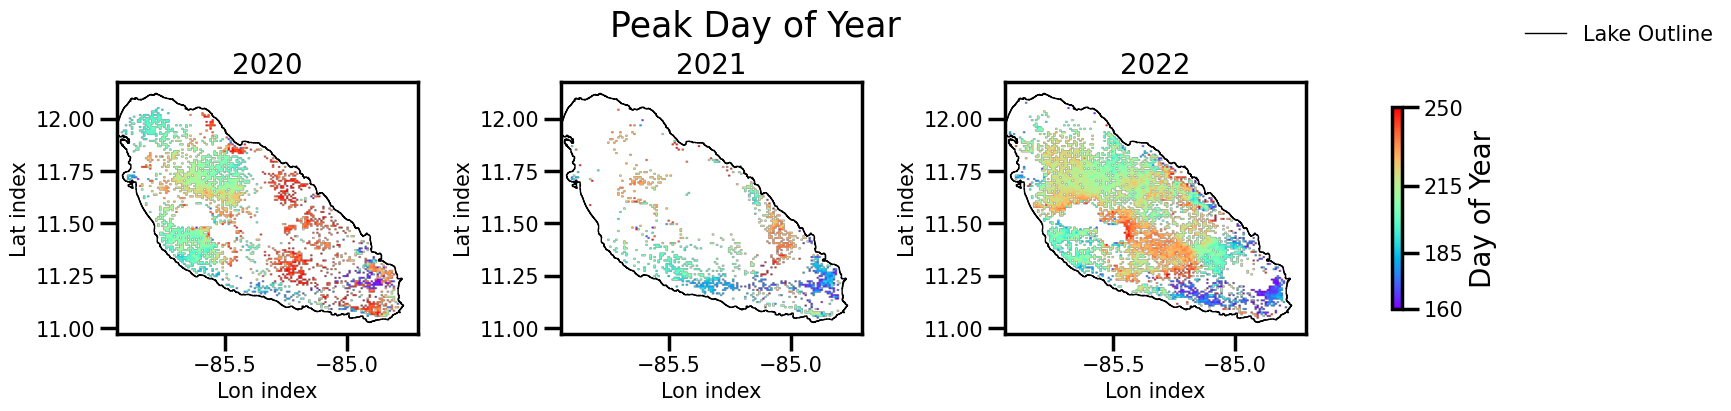

[Text(0, 10.75, ''),
 Text(0, 11.0, ''),
 Text(0, 11.25, ''),
 Text(0, 11.5, ''),
 Text(0, 11.75, ''),
 Text(0, 12.0, ''),
 Text(0, 12.25, '')]

In [10]:
# Compare single years
%matplotlib inline
years = [2020,2021,2022]
sns.set_context('poster')
fig ,axs = chla_v3.time_map_panel(years = years, ncol = 3, nrow = 1)
plt.show()
axs = axs[0]
# plt.show()
fig.suptitle('')
fig.legend().remove()
axs[0].legend().remove()
axs[2].legend().remove()
axs[1].legend().remove()
axs[1].set_ylabel('')
axs[1].set_yticklabels([])
axs[2].set_ylabel('')
axs[2].set_yticklabels([])


### Plotting a single day of data.
Move the code into the PhenologyVisualization class

In [20]:
# choose a date you would like to analyze
phyco_v3.create_DataFrame(i,j)

,Value,Variable,latitude,longitude,lake_ID
Time,,,,,
2003-02-20 00:00:00+00:00,0.689285,green_down_advanced,46.970833,18.029167,310
2004-02-12 00:00:00+00:00,0.863320,green_down_advanced,46.970833,18.029167,310
2005-02-03 00:00:00+00:00,1.291469,green_down_advanced,46.970833,18.029167,310
2005-12-11 00:00:00+00:00,0.579281,green_down_advanced,46.970833,18.029167,310
2007-04-16 00:00:00+00:00,0.686765,green_down_advanced,46.970833,18.029167,310
...,...,...,...,...,...
2021-05-25 00:00:00+00:00,0.194586,trgs,46.970833,18.029167,310
2021-11-04 00:00:00+00:00,0.302125,trgs,46.970833,18.029167,310
2022-05-15 00:00:00+00:00,0.284230,trgs,46.970833,18.029167,310


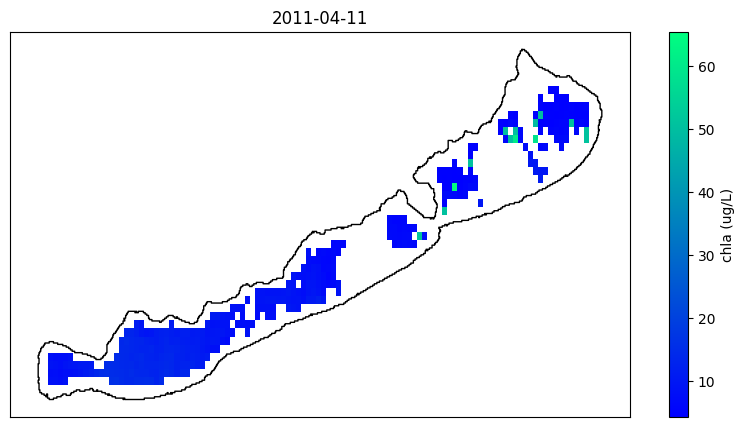

In [21]:
series = chla_v3.load_pixel_data(i, j)
chla_v3.single_day_map(series.idxmax())


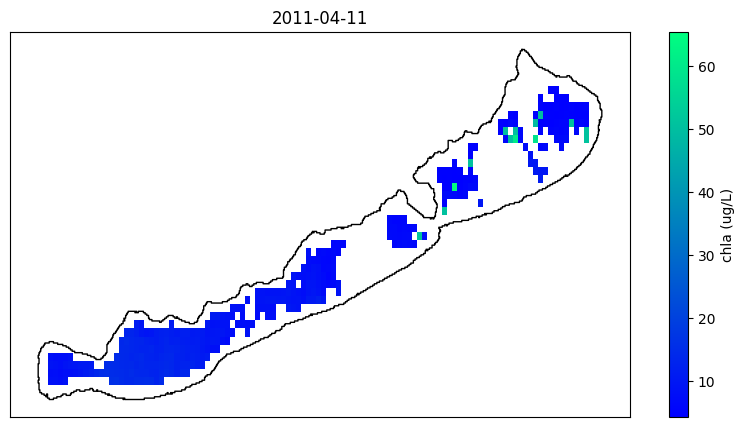

In [22]:
#same map but date is manually chosen

manual_date = pd.to_datetime('11-04-2011', format = "%d-%m-%Y")
chla_v3.single_day_map(manual_date)


## Heatmaps
Create heatmaps on a pixel and lake level

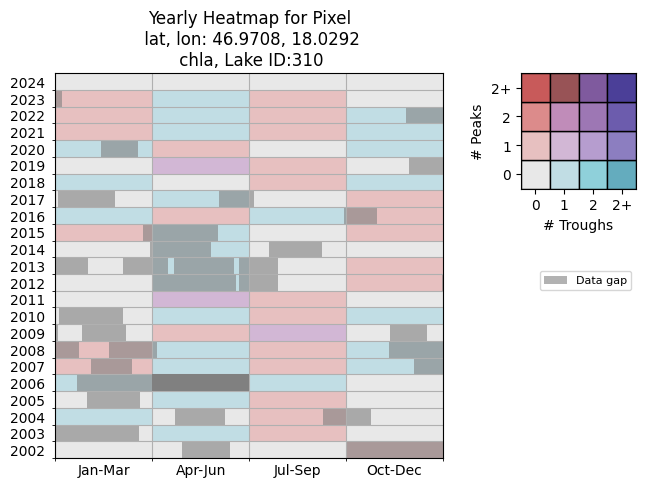

In [ ]:
fig, ax = chla_v3.yearly_heatmap_pixel(latitude_idx=i, longitude_idx=j, color_scheme='teal-red', show_gaps=True)
plt.show()

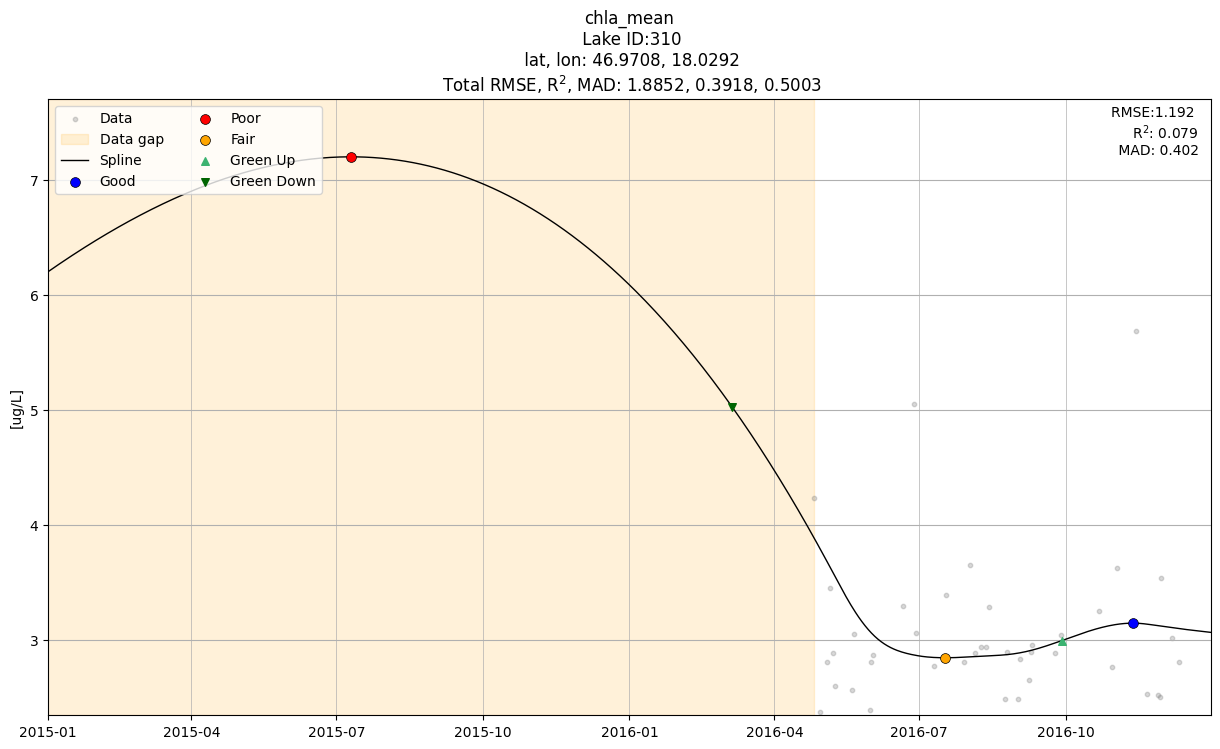

In [19]:
fig, ax = plt.subplots(figsize = (15,8))

chla_v2.single_plot(i,j, ax, start = 2015, end = 2016
                    
                    )

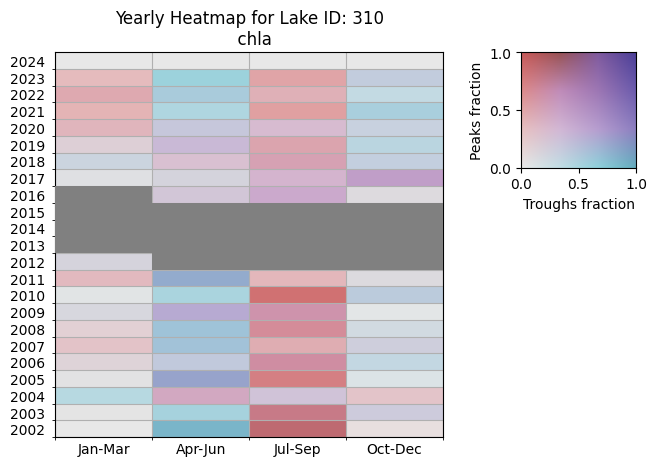

In [ ]:

modis_gap = ["2012 Apr-Jun", "2012 Jul-Sep", "2012 Oct-Dec","2013 Jan-Mar", "2013 Apr-Jun", 
             "2013 Jul-Sep", "2013 Oct-Dec","2014 Jan-Mar","2014 Apr-Jun", "2014 Jul-Sep", 
             "2014 Oct-Dec","2015 Jan-Mar","2015 Apr-Jun", "2015 Jul-Sep", "2015 Oct-Dec", "2016 Jan-Mar"]

fig, ax = chla_v3.yearly_heatmap_lake(color_scheme='teal-red', qa = {0}, mask_cells=modis_gap)
plt.show()

## Kernel Density Plots

plotting started at: 2026-08-03 16:48:43.389816
C:\Users\sparksno\Desktop\analysis_test\lake_analysis\ID310_Balaton\calculated_values\kde_data\v3.0\chla\kde_events.csv
C:\Users\sparksno\Desktop\analysis_test\lake_analysis\ID310_Balaton\calculated_values\kde_data\v3.0\chla\kde_events.csv
20377
plotting ended at: 2026-08-03 16:48:47.116015


<Axes: title={'center': 'chla v3.0 - Green-up Advanced vs Green-down Onset\nLake ID: 310 | 2002 - 2023 | QA: Good, Fair'}, xlabel='Green-up Advanced (DOY)', ylabel='Green-down Onset (DOY)'>

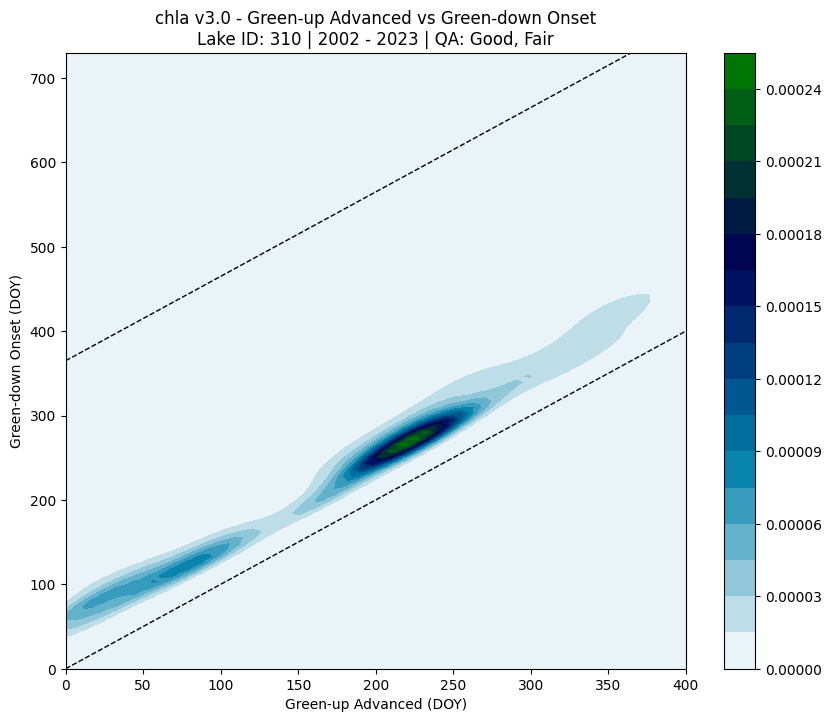

In [ ]:
%matplotlib inline
fig, ax = plt.subplots(figsize= (10,8))

chla_v3.lake_bloom_kde(ax, qa_value = {0,1})

plotting started at: 2026-08-03 17:06:30.468011
C:\Users\sparksno\Desktop\analysis_test\lake_analysis\ID310_Balaton\calculated_values\kde_data\v3.0\chla\kde_events.csv
C:\Users\sparksno\Desktop\analysis_test\lake_analysis\ID310_Balaton\calculated_values\kde_data\v3.0\chla\kde_events.csv
13059


<Axes: title={'center': 'Bloom event probability per 21-day interval\nLake ID: 310'}, xlabel='Green-up Advanced (DOY)', ylabel='Green-down Onset (DOY)'>

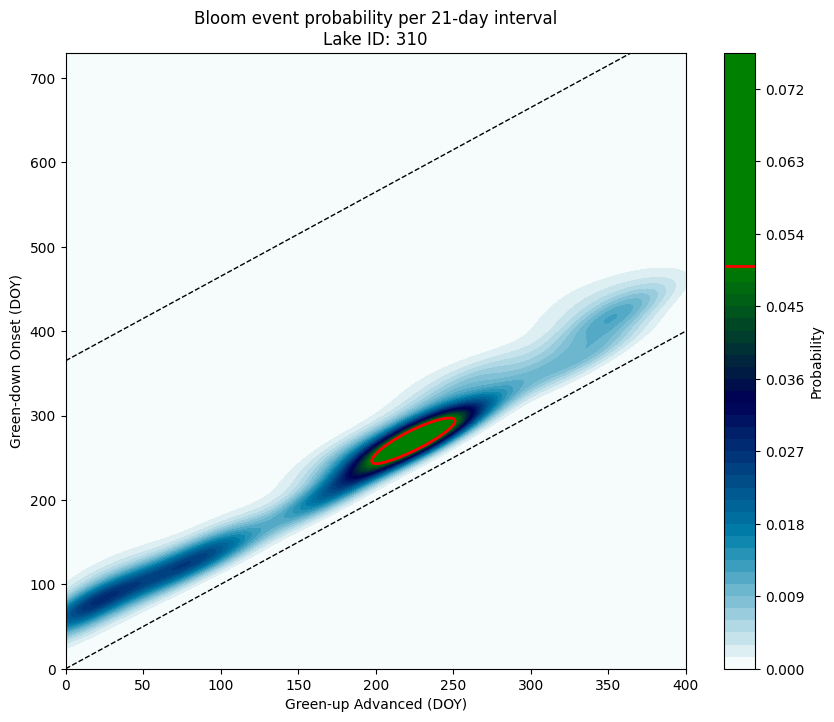

In [9]:
# plot KDE with probability
fig, ax = plt.subplots(figsize= (10,8))

chla_v3.lake_bloom_kde(ax, qa_value = {0}, probability = True)

## Comparative plots

In [25]:

phyco_series = phyco_v3.load_pixel_data(i,j)
chla_series = chla_v3.load_pixel_data(i,j)
meris_sensor = chla_series.index.year < 2013

In [26]:
df_to_plot = pd.concat([chla_series,phyco_series],axis=1)
df_to_plot.columns = ['chla','phyco']
df_to_plot['year'] = df_to_plot.index.year
df_to_plot['meris_period'] = df_to_plot['year'] < 2013

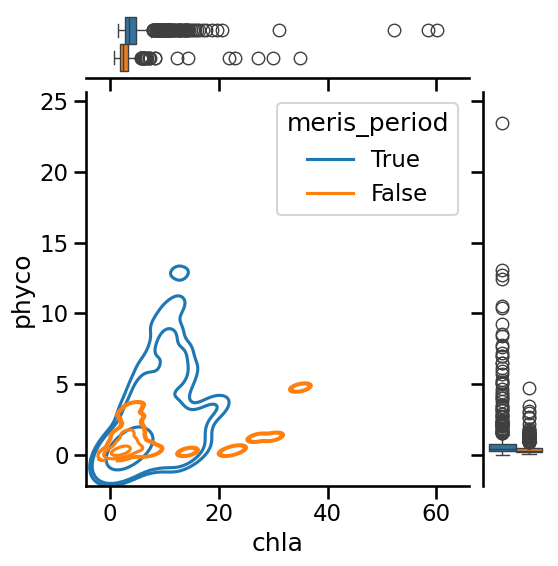

In [27]:
sns.set_context("talk")
g = sns.JointGrid(df_to_plot, x= "chla",y="phyco",hue="meris_period",hue_order=[True,False],height=6)
g.plot_joint(sns.kdeplot,levels=[0.005,0.01,0.1,0.5])
g.plot_marginals(sns.boxplot)

## Plot CCI lakes

In [39]:
ca_countries = ['Kazakhstan','Kyrgyzstan','Tajikistan','Turkmenistan','Uzbekistan']
ca_country_query = "Kazakhstan|Kyrgyzstan|Tajikistan|Turkmenistan|Uzbekistan"

In [54]:
ca_gdf = chla_v3.gdf.loc[chla_v3.gdf["country"].str.contains(ca_country_query)]

In [76]:
nkz = ca_gdf.cx[:,50:]
print(len(nkz))

24


In [73]:
def plot_location_map(subset_gdf,title_label=''):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

    minx, miny, maxx, maxy = subset_gdf.total_bounds
    pad = 0.5
    ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

    subset_gdf.plot(ax=ax, transform=ccrs.PlateCarree(), color="steelblue", edgecolor="black", linewidth=0.5)

    for _, row in subset_gdf.iterrows():
        label = row["name"] if row["name"] else f"ID {row['id']}"
        c = row.geometry.centroid
        ax.annotate(label, xy=(c.x, c.y), xytext=(3, 3), textcoords="offset points", fontsize=6,
                    transform=ccrs.PlateCarree())

    ax.set_title(f"CCI Lakes in {title_label} (n={len(ca)})")
    return ax

<GeoAxes: title={'center': 'CCI Lakes in Central Asia (n=61)'}>

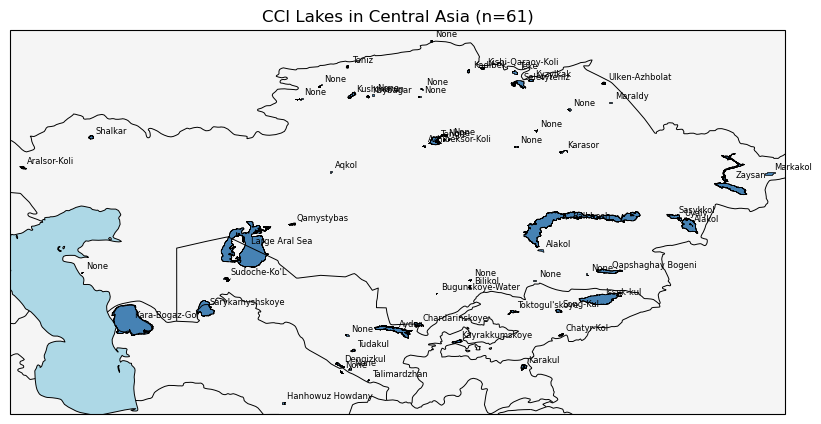

In [78]:
ca_country_query = "Kazakhstan|Kyrgyzstan|Tajikistan|Turkmenistan|Uzbekistan"
ca = chla_v3.gdf.loc[chla_v3.gdf["country"].str.contains(ca_country_query)]

plot_location_map(ca,'Central Asia')

C:\Users\schelian\AppData\Local\Temp\ipykernel_28200\1481618107.py:2: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(bottom=48)


(45.6, 50.4)

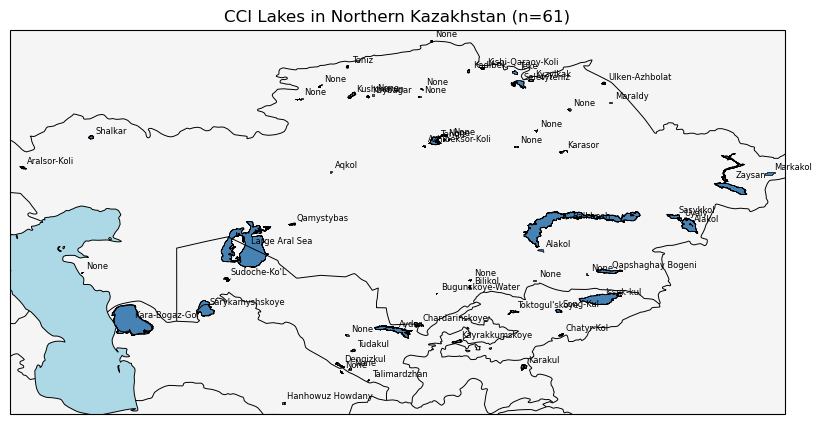

In [81]:
plot_location_map(ca,'Northern Kazakhstan')
ax.set_ylim(bottom=48)

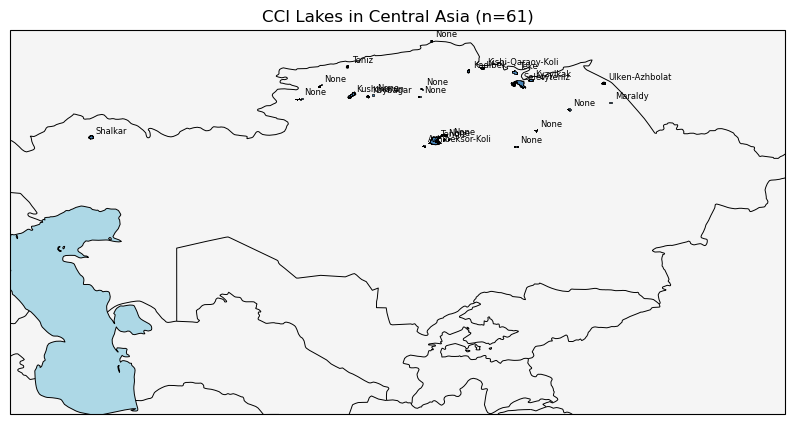

In [71]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

ca_country_query = "Kazakhstan|Kyrgyzstan|Tajikistan|Turkmenistan|Uzbekistan"
ca = chla_v3.gdf.loc[chla_v3.gdf["country"].str.contains(ca_country_query)]

minx, miny, maxx, maxy = ca.total_bounds
pad = 0.5
ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

nkz.plot(ax=ax, transform=ccrs.PlateCarree(), color="steelblue", edgecolor="black", linewidth=0.5)

for _, row in nkz.iterrows():
    label = row["name"] if row["name"] else f"ID {row['id']}"
    c = row.geometry.centroid
    ax.annotate(label, xy=(c.x, c.y), xytext=(3, 3), textcoords="offset points", fontsize=6,
                transform=ccrs.PlateCarree())

ax.set_title(f"CCI Lakes in Central Asia (n={len(ca)})")
plt.show()

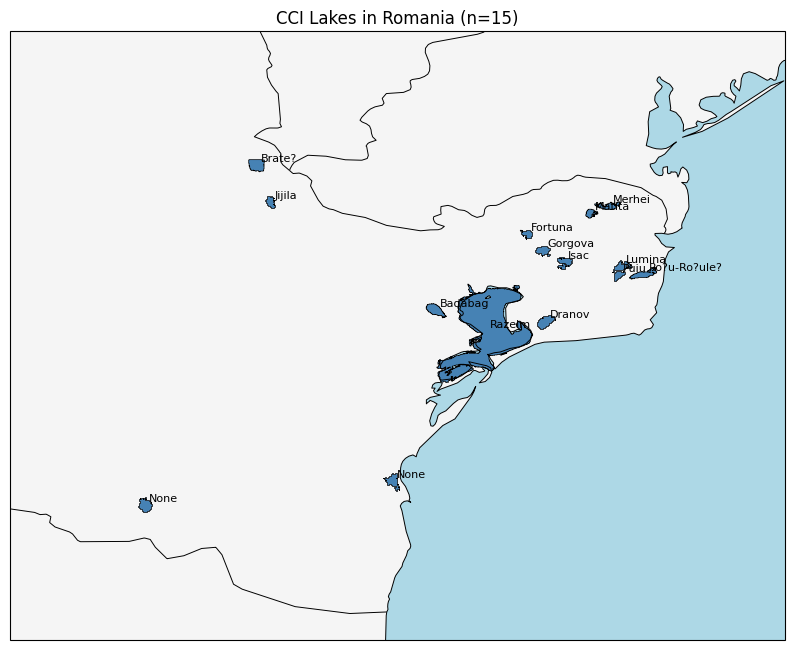

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})

ro = chla_v3.gdf[chla_v3.gdf["country"] == "Romania"]

minx, miny, maxx, maxy = ro.total_bounds
pad = 0.5
ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.BORDERS, linewidth=0.7)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)

ro.plot(ax=ax, transform=ccrs.PlateCarree(), color="steelblue", edgecolor="black", linewidth=0.5)

for _, row in ro.iterrows():
    label = row["name"] if row["name"] else f"ID {row['id']}"
    c = row.geometry.centroid
    ax.annotate(label, xy=(c.x, c.y), xytext=(3, 3), textcoords="offset points", fontsize=8,
                transform=ccrs.PlateCarree())

ax.set_title(f"CCI Lakes in Romania (n={len(ro)})")
plt.show()